## 1. Install libraries

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn -q

## 2. Library Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.datasets import load_iris
from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

# Metrics for clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings('ignore')

## 3. Dataset Import

In [3]:
# Loading the Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)

print("Dataset shape:", X.shape)
print("\nFeature names:")
print(X.columns.tolist())
print("\nDataset info:")
print(X.describe())

Dataset shape: (150, 4)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Dataset info:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [4]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## 4. Data preprocessing

In [5]:
# Check for missing values
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


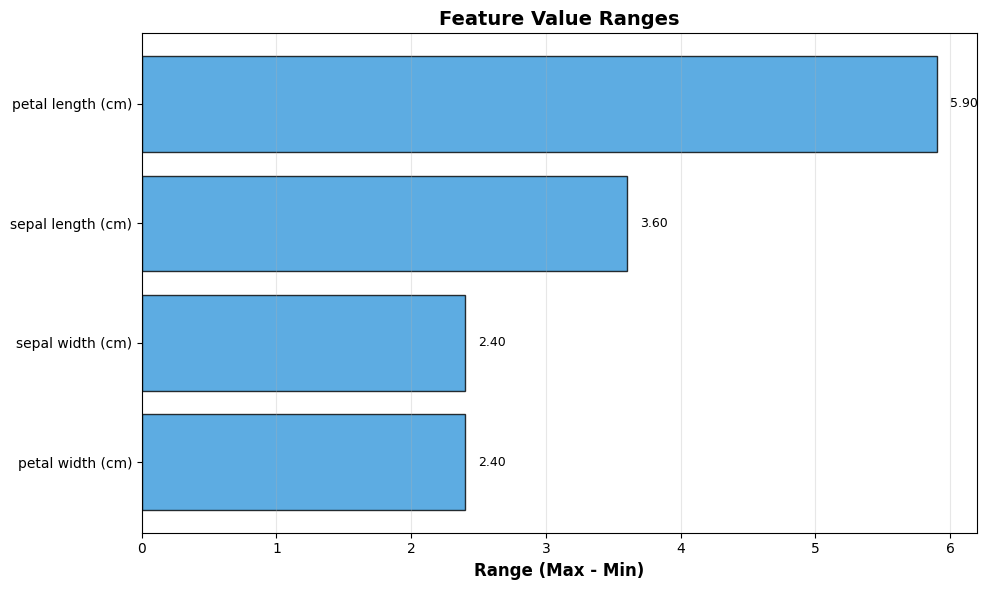

Feature scaling analysis completed.


In [6]:
# Check feature scaling

# Calculate min and max for each feature
feature_ranges = pd.DataFrame({
    'Feature': X.columns,
    'Min': X.min().values,
    'Max': X.max().values,
    'Range': (X.max() - X.min()).values
})

# Sort by range in descending order
feature_ranges = feature_ranges.sort_values('Range', ascending=True)

# Create barplot
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(feature_ranges))
ax.barh(y_pos, feature_ranges['Range'], color='#3498db', alpha=0.8, edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_ranges['Feature'])
ax.set_xlabel('Range (Max - Min)', fontsize=12, fontweight='bold')
ax.set_title('Feature Value Ranges', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(feature_ranges.iterrows()):
    ax.text(row['Range'] + 0.1, i, f"{row['Range']:.2f}", va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('feature_ranges.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature scaling analysis completed.")

Feature scaling will be applied within the 5-fold CV loop.

## 5. Exploratory Data Analysis (EDA)

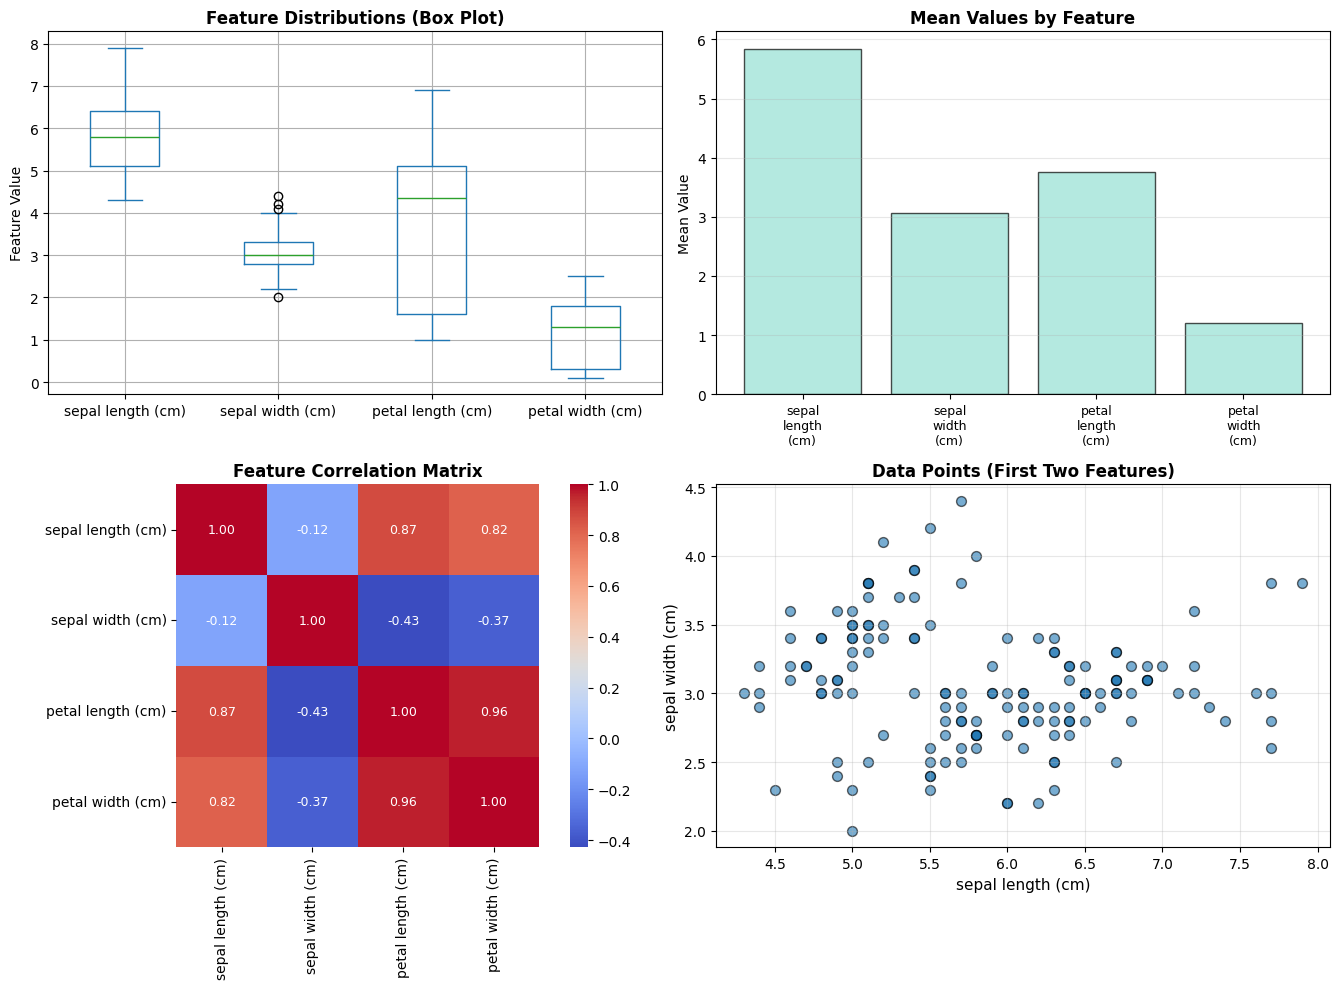

In [7]:
# Create a figure with subplots for EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 - Feature distributions
ax = axes[0, 0]
X.plot(kind='box', ax=ax, grid=True)
ax.set_title('Feature Distributions (Box Plot)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Value')

# 5.2 - Feature statistics
ax = axes[0, 1]
feature_means = X.mean()
ax.bar(range(len(feature_means)), feature_means.values, color='#95E1D3', alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(feature_means)))
ax.set_xticklabels([name.replace(' ', '\n') for name in feature_means.index], fontsize=9)
ax.set_title('Mean Values by Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Value')
ax.grid(axis='y', alpha=0.3)

# 5.3 - Feature correlation heatmap
ax = axes[1, 0]
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, ax=ax, square=True, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# 5.4 - PCA-like visualization (first two features)
ax = axes[1, 1]
scatter = ax.scatter(X.iloc[:, 0], X.iloc[:, 1], alpha=0.6, edgecolor='black', s=50)
ax.set_xlabel(X.columns[0], fontsize=11)
ax.set_ylabel(X.columns[1], fontsize=11)
ax.set_title('Data Points (First Two Features)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

#print("EDA completed and saved as 'eda_overview.png'")

## 6. Model Training with 5-Fold Cross Validation

In [8]:
# Initialize K-means clusterer with 3 clusters (number of classes in Iris dataset)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# 5-Fold Cross Validation (using regular KFold for unsupervised learning)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []
train_times = []
predict_times = []
inertias = []

print("Running 5-Fold Cross Validation with K-means (k=3)...\n")

for fold_num, (train_idx, test_idx) in enumerate(cv.split(X), 1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    # Apply RobustScaler to training data
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train K-means on training data
    start_time = time()
    kmeans.fit(X_train_scaled)
    train_time = time() - start_time

    # Predict labels on test data
    start_time = time()
    test_labels = kmeans.predict(X_test_scaled)
    predict_time = time() - start_time

    # Calculate clustering metrics
    silhouette = silhouette_score(X_test_scaled, test_labels)
    davies_bouldin = davies_bouldin_score(X_test_scaled, test_labels)
    calinski_harabasz = calinski_harabasz_score(X_test_scaled, test_labels)
    inertia = kmeans.inertia_

    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_harabasz_scores.append(calinski_harabasz)
    train_times.append(train_time)
    predict_times.append(predict_time)
    inertias.append(inertia)

    # print(f"Fold {fold_num}:")
    # print(f"  Silhouette Score: {silhouette:.4f}")
    # print(f"  Davies-Bouldin Index: {davies_bouldin:.4f}")
    # print(f"  Calinski-Harabasz Index: {calinski_harabasz:.4f}")
    # print()

# Aggregate results
results = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Mean': [np.mean(silhouette_scores), np.mean(davies_bouldin_scores), np.mean(calinski_harabasz_scores)],
    'Std': [np.std(silhouette_scores), np.std(davies_bouldin_scores), np.std(calinski_harabasz_scores)]
}

print("=" * 60)
print("CROSS-VALIDATION SUMMARY")
print("=" * 60)
print(f"Silhouette Score: {np.mean(silhouette_scores):.4f} (+/- {np.std(silhouette_scores):.4f})")
print(f"Davies-Bouldin Index: {np.mean(davies_bouldin_scores):.4f} (+/- {np.std(davies_bouldin_scores):.4f})")
print(f"Calinski-Harabasz Index: {np.mean(calinski_harabasz_scores):.4f} (+/- {np.std(calinski_harabasz_scores):.4f})")
print(f"Avg Training Time: {np.mean(train_times):.6f}s")
print(f"Avg Prediction Time: {np.mean(predict_times):.6f}s")

Running 5-Fold Cross Validation with K-means (k=3)...

CROSS-VALIDATION SUMMARY
Silhouette Score: 0.4426 (+/- 0.0212)
Davies-Bouldin Index: 0.7972 (+/- 0.0519)
Calinski-Harabasz Index: 38.1898 (+/- 7.3632)
Avg Training Time: 0.045900s
Avg Prediction Time: 0.000571s


## 7. Results summary

In [9]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display results table
print("=" * 80)
print("TABLE 1: CLUSTERING EVALUATION METRICS (5-Fold Cross Validation)")
print("=" * 80)
print(results_df.to_string(index=False))
print()

# Computational time table
time_df = pd.DataFrame({
    'Metric': ['Training Time', 'Prediction Time'],
    'Mean (s)': [np.mean(train_times), np.mean(predict_times)],
    'Std (s)': [np.std(train_times), np.std(predict_times)]
})

print("=" * 80)
print("TABLE 2: COMPUTATIONAL TIME")
print("=" * 80)
print(time_df.to_string(index=False))
print()

# Inertia values
inertia_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(len(inertias))],
    'Inertia': inertias
})

print("=" * 80)
print("TABLE 3: INERTIA VALUES BY FOLD")
print("=" * 80)
print(inertia_df.to_string(index=False))
print(f"\nMean Inertia: {np.mean(inertias):.4f} (+/- {np.std(inertias):.4f})")

TABLE 1: CLUSTERING EVALUATION METRICS (5-Fold Cross Validation)
                 Metric      Mean      Std
       Silhouette Score  0.442584 0.021210
   Davies-Bouldin Index  0.797230 0.051879
Calinski-Harabasz Index 38.189819 7.363160

TABLE 2: COMPUTATIONAL TIME
         Metric  Mean (s)  Std (s)
  Training Time  0.045900 0.033482
Prediction Time  0.000571 0.000184

TABLE 3: INERTIA VALUES BY FOLD
  Fold   Inertia
Fold 1 46.960029
Fold 2 73.056960
Fold 3 56.411773
Fold 4 48.862054
Fold 5 46.939439

Mean Inertia: 54.4461 (+/- 9.9378)


## 8. Visualization of Results

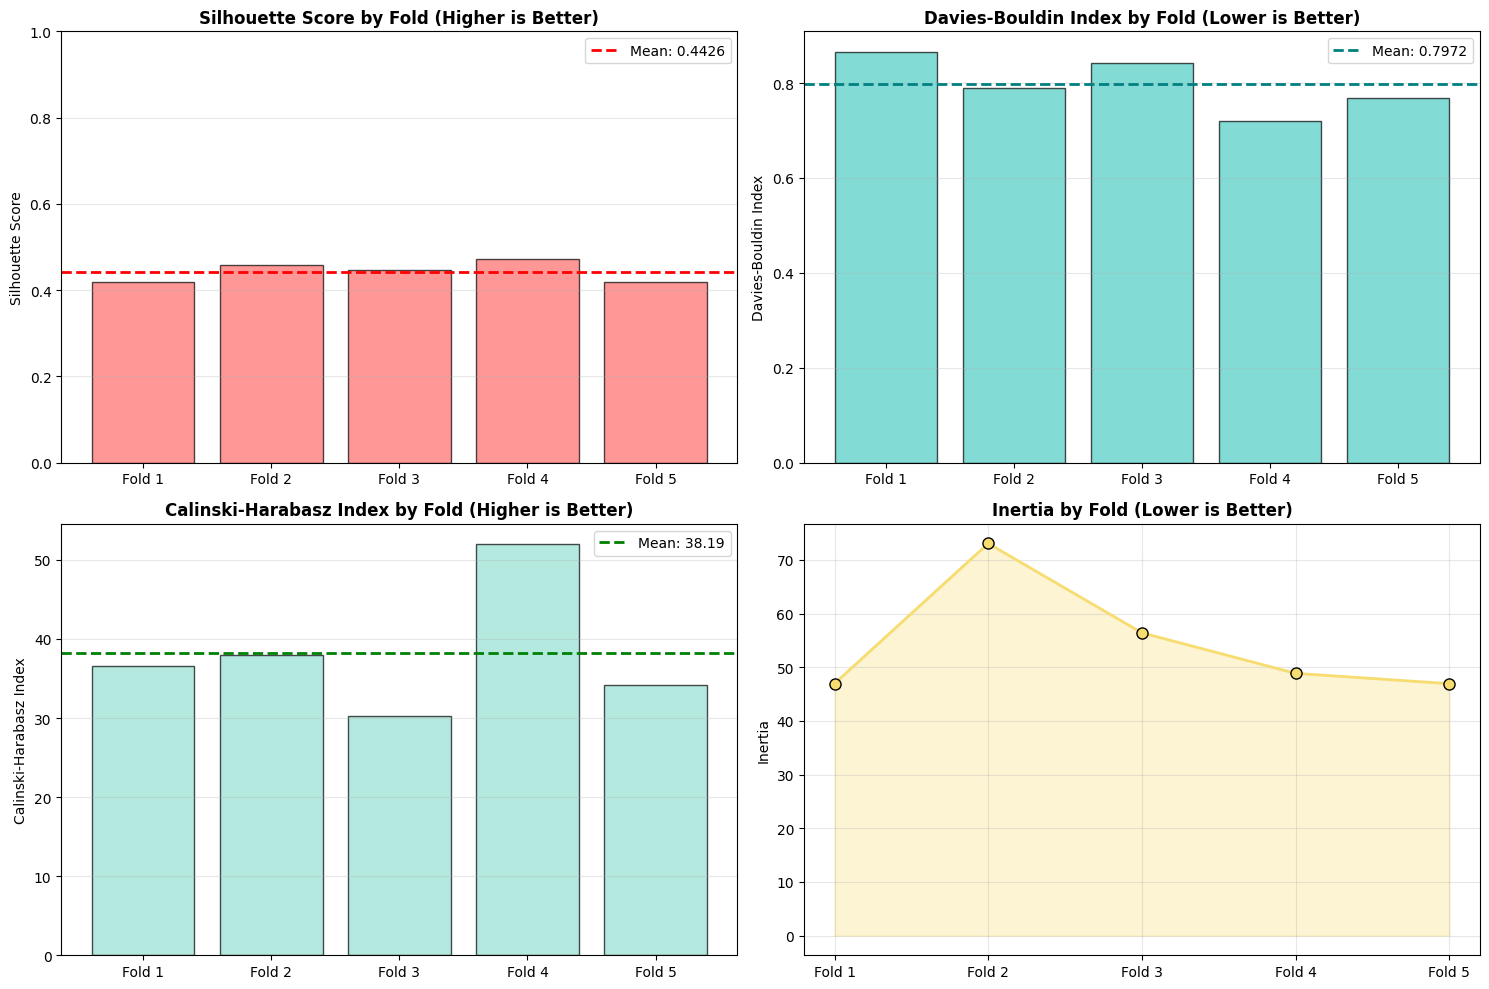

In [10]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 8.1 - Silhouette Score by Fold
ax = axes[0, 0]
folds = [f'Fold {i+1}' for i in range(len(silhouette_scores))]
x_pos = np.arange(len(folds))
ax.bar(x_pos, silhouette_scores, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(silhouette_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(silhouette_scores):.4f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score by Fold (Higher is Better)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.legend()

# 8.2 - Davies-Bouldin Index by Fold
ax = axes[0, 1]
ax.bar(x_pos, davies_bouldin_scores, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(davies_bouldin_scores), color='teal', linestyle='--', linewidth=2, label=f'Mean: {np.mean(davies_bouldin_scores):.4f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin Index by Fold (Lower is Better)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend()

# 8.3 - Calinski-Harabasz Index by Fold
ax = axes[1, 0]
ax.bar(x_pos, calinski_harabasz_scores, color='#95E1D3', alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(calinski_harabasz_scores), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(calinski_harabasz_scores):.2f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Calinski-Harabasz Index')
ax.set_title('Calinski-Harabasz Index by Fold (Higher is Better)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend()

# 8.4 - Inertia by Fold
ax = axes[1, 1]
ax.plot(x_pos, inertias, marker='o', linewidth=2, markersize=8, color='#F7DC6F', markeredgecolor='black')
ax.fill_between(x_pos, inertias, alpha=0.3, color='#F7DC6F')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Inertia')
ax.set_title('Inertia by Fold (Lower is Better)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

#print("Visualization completed and saved as 'clustering_evaluation.png'")

## Exercício

---


Para melhorar o Calinski-Harabasz precisa focar na separação entre os clusters e na densidade interna deles, pois o valor do indice é a razão entre a dispersão entre-clusters e a dispersão intra-cluster. Os **clusters** são caracteristicas dos dados, então novamente será preciso normalizar a base de dados usando `StandardScaler`, pois ao normalizar através da média e o desvio padrão ajuda o algoritmo a ter o "0 como centro" dos dados. Além disso, irei aumentar `n_init` e o `max_iter` no **Kmeans** para ter uma inicialização dos centroides com maior cobertura, pois ao passa `init='k-means++'`, apenas o primeiro centroide é aleatoriamente, o proximo centroide busca ser o "mais longe possivel" e assim sucessivamente (os 30 centroides iniciais).

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ch_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]

    kmeans = KMeans(
        n_clusters=3,
        init='k-means++',
        n_init=30,
        max_iter=500,
        random_state=42
    )

    kmeans.fit(X_train)
    labels = kmeans.predict(X_test)

    ch_score = calinski_harabasz_score(X_test, labels)
    ch_scores.append(ch_score)

print(f'Calinski-Harabasz Index Médio Otimizado: {np.mean(ch_scores):.2f}')

Calinski-Harabasz Index Médio Otimizado: 48.05


### Visualização

---

Veja conseguimos melhorar para 48,05% o indice Calinski-Harabasz.

In [23]:
def plot_folds(scores, model_name="Modelo", metric_name="Calinski-Harabasz Index"):

    folds = [f'Fold {i+1}' for i in range(len(scores))]
    x_pos = np.arange(len(folds))

    plt.figure(figsize=(10, 6))

    bars = plt.bar(x_pos, scores, color='#95E1D3', edgecolor='black', alpha=0.8)

    mean_val = np.mean(scores)
    plt.axhline(mean_val, color='#E74C3C', linestyle='--', linewidth=2,
                label=f'Média: {mean_val:.2f}')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (max(scores) * 0.02),
                 f'{height:.2f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

    plt.title(f'{metric_name} por Fold - {model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Folds da Validação Cruzada', fontsize=12)
    plt.ylabel(f'Score ({metric_name})', fontsize=12)
    plt.xticks(x_pos, folds)


    plt.ylim(0, max(scores) * 1.2)

    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')


    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

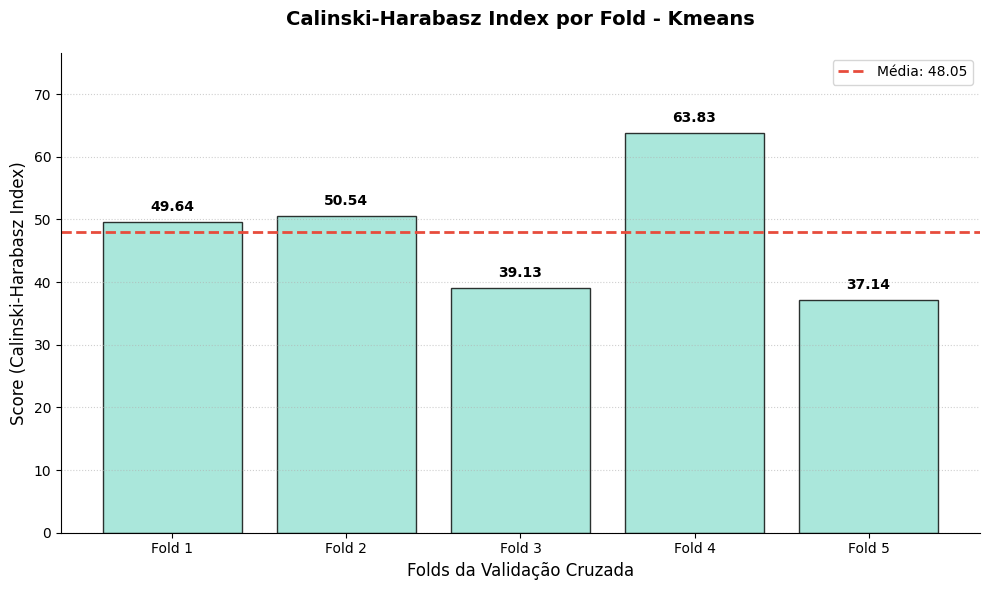

In [25]:
plot_folds(ch_scores,"Kmeans")

### Outros algoritmos
---

Agora irei aplicar o mesmo procesamento para BIRCH, Agglomerative, GMM

In [18]:
from sklearn.cluster import Birch

ch_scores_birch = []

#mesmo kf do inicio do exercicio
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]

    birch = Birch(
        threshold=0.5,
        branching_factor=50,
        n_clusters=3
    )


    birch.fit(X_train)
    labels = birch.predict(X_test)

    score = calinski_harabasz_score(X_test, labels)
    ch_scores_birch.append(score)

print(f'Calinski-Harabasz Index Médio (BIRCH): {np.mean(ch_scores_birch):.2f}')

Calinski-Harabasz Index Médio (BIRCH): 40.68


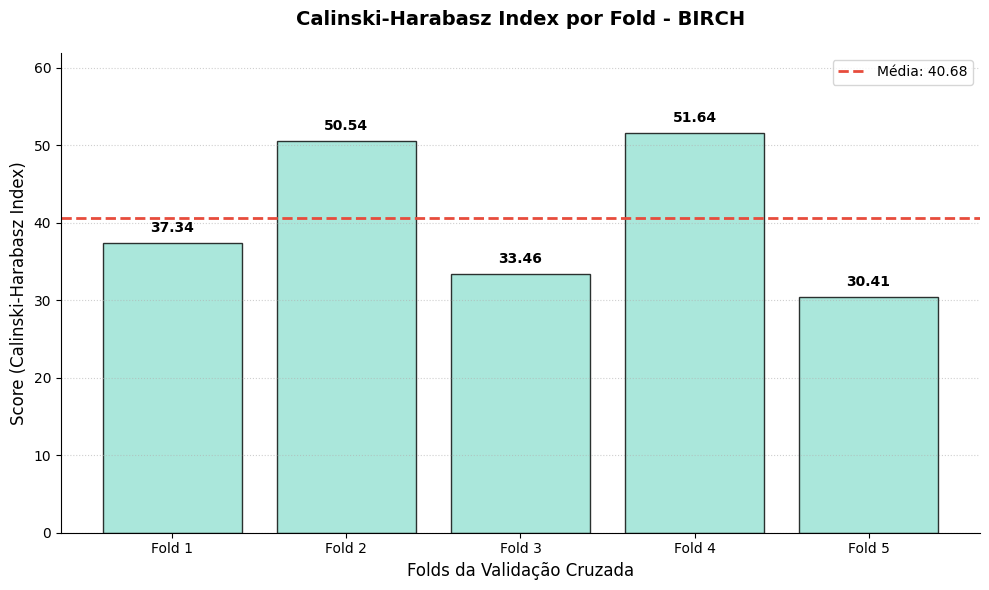

In [26]:
plot_folds(ch_scores_birch, "BIRCH")

In [19]:
from sklearn.cluster import AgglomerativeClustering

ch_scores_agg = []

#mesmo kf do inicio do exercicio
for train_index, test_index in kf.split(X_scaled):
    X_test = X_scaled[test_index]

    agg = AgglomerativeClustering(
        n_clusters=3,
        linkage='ward'
    )

    labels = agg.fit_predict(X_test)

    score = calinski_harabasz_score(X_test, labels)
    ch_scores_agg.append(score)

print(f'Calinski-Harabasz Index Médio (Agglomerative): {np.mean(ch_scores_agg):.2f}')

Calinski-Harabasz Index Médio (Agglomerative): 47.06


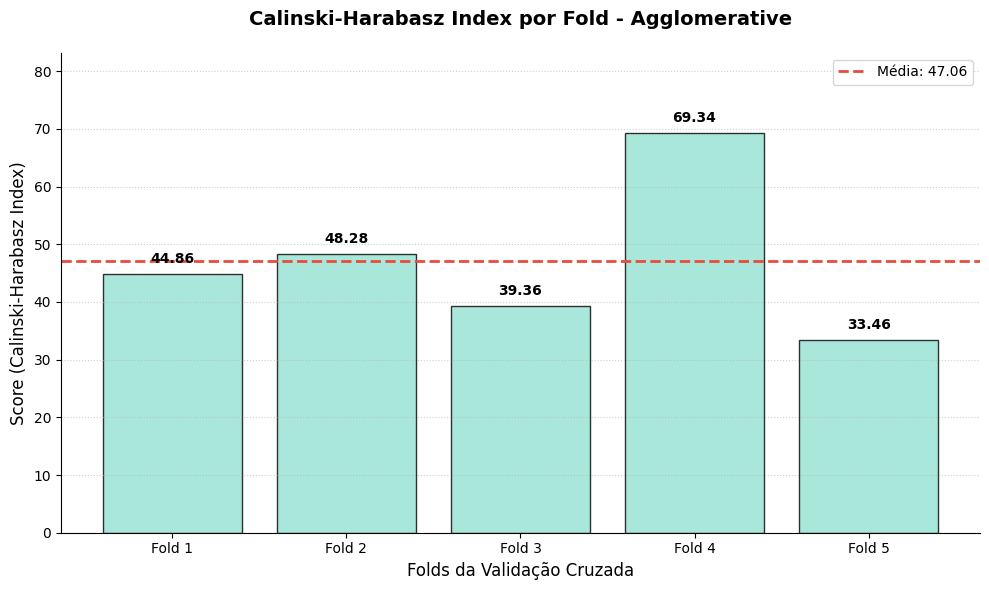

In [27]:
plot_folds(ch_scores_agg, "Agglomerative")

In [28]:
from sklearn.mixture import GaussianMixture

ch_scores_gmm = []

#mesmo kf do inicio do exercicio
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]

    gmm = GaussianMixture(
        n_components=3,
        covariance_type='full',
        n_init=10,
        random_state=42
    )


    gmm.fit(X_train)
    labels = gmm.predict(X_test)

    score = calinski_harabasz_score(X_test, labels)
    ch_scores_gmm.append(score)

print(f'Calinski-Harabasz Index Médio (GMM): {np.mean(ch_scores_gmm):.2f}')

Calinski-Harabasz Index Médio (GMM): 33.89


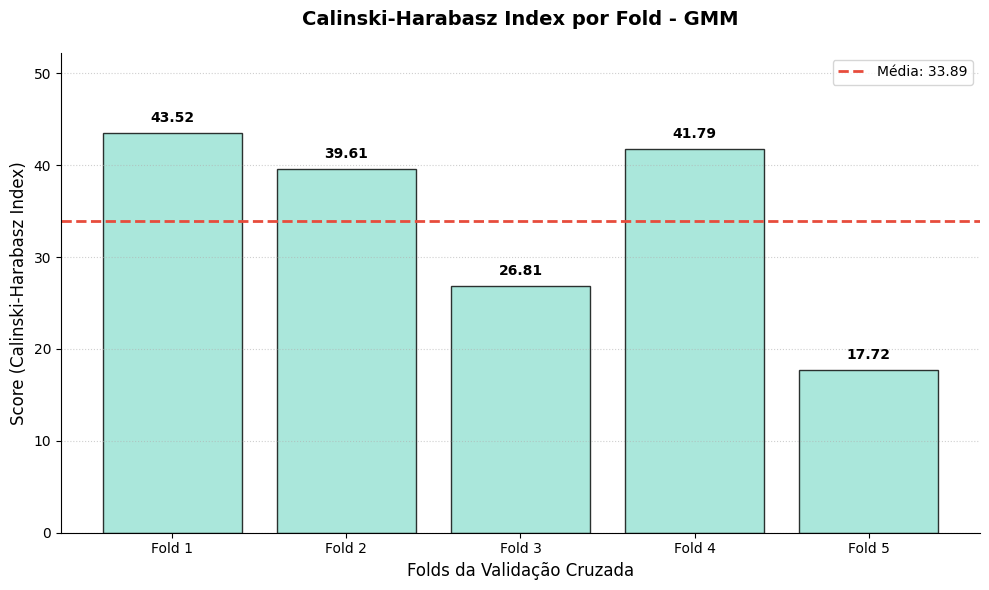

In [29]:
plot_folds(ch_scores_gmm, "GMM")

Após a execução de todos os algoritmos, o que melhor performou foi o **Kmeans** com média de 48,05
